In [1]:
import os
import time
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Subset
from torchvision.utils import make_grid
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, random_split, DataLoader

from PIL import Image
from collections import OrderedDict
%matplotlib inline

In [2]:
from google.colab import drive
# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# # Transform Settings - Do not use RandomResizedCrop
# transform = transforms.Compose([
#             transforms.Resize((224,224)), 
#             transforms.ToTensor()
#             ])

# dataset = ImageFolder('/content/drive/MyDrive/APS360/APS360 Project/Final_dataset', transform=transform)

# breeds = []

# def rename(name):
#     return ' '.join(' '.join(name.split('-')[1:]).split('_'))

# for n in dataset.classes:
#     breeds.append(rename(n))
# print(breeds)

https://datahacker.rs/017-pytorch-how-to-apply-batch-normalization-in-pytorch/
show_batch, mean_std, and batch normalization

In [4]:
# def show_batch(dl):
#     for img, lb in dl:
#         fig, ax = plt.subplots(figsize=(16, 8))
#         ax.set_xticks([]); ax.set_yticks([])
#         ax.imshow(make_grid(img.cpu(), nrow=16).permute(1,2,0))
#         break
#
# all_loader = torch.utils.data.DataLoader(dataset, 32, shuffle=True)
# show_batch(all_loader)

In [5]:
# all_loader = torch.utils.data.DataLoader(dataset, 128, shuffle=True)
# # Normalization Calculation
# def mean_std(loader):
#   sum, squared_sum, num_batches = 0,0,0
#   for data,_ in loader:
#     sum += torch.mean(data,dim=[0,2,3])
#     squared_sum += torch.mean(data**2,dim=[0,2,3])
#     num_batches += 1
#   mean = sum/num_batches
#   std = (squared_sum/num_batches - mean**2)**0.5
#   return mean, std

# # mean, std = mean_std(all_loader)
# # print(mean)
# # print(std)

# # Takes 20 min to calculate
# # tensor([0.4719, 0.4453, 0.3887])
# # tensor([0.2585, 0.2533, 0.2609])

In [6]:
mean = [0.4719, 0.4453, 0.3887]
std= [0.2585, 0.2533, 0.2609]

In [7]:
# Transform Settings - Do not use RandomResizedCrop
transform = transforms.Compose([
            transforms.Resize((224,224)), 
            transforms.ToTensor(),
            transforms.Normalize((mean),(std))
            ])

dataset = ImageFolder('/content/drive/MyDrive/APS360/APS360 Project/Final_dataset', transform=transform)

breeds = []

def rename(name):
    return ' '.join(' '.join(name.split('-')[1:]).split('_'))

for n in dataset.classes:
    breeds.append(rename(n))
print(breeds)

['Chihuahua', 'Maltese dog', 'Shih Tzu', 'Rhodesian ridgeback', 'basset', 'beagle', 'bloodhound', 'Weimaraner', 'Yorkshire terrier', 'Boston bull', 'miniature schnauzer', 'West Highland white terrier', 'golden retriever', 'Labrador retriever', 'Chesapeake Bay retriever', 'German short haired pointer', 'vizsla', 'Brittany spaniel', 'English springer', 'Welsh springer spaniel', 'cocker spaniel', 'malinois', 'Shetland sheepdog', 'collie', 'Border collie', 'Rottweiler', 'German shepherd', 'Doberman', 'Bernese mountain dog', 'boxer', 'bull mastiff', 'French bulldog', 'Great Dane', 'Siberian husky', 'pug', 'Newfoundland', 'Samoyed', 'Pomeranian', 'Pembroke', 'standard poodle']


In [8]:
#Split Train/Valid/Test Dataset
random_seed = 45
torch.manual_seed(random_seed);
test_pct = 0.15
test_size = int(len(dataset)*test_pct)
dataset_size = len(dataset) - test_size

val_pct = 0.15
val_size = int(dataset_size*val_pct)
train_size = dataset_size - val_size
train_size, val_size, test_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(train_ds), len(val_ds), len(test_ds)

(4956, 874, 1028)

In [9]:
# Show Image
# train_loader = torch.utils.data.DataLoader(train_ds, 32, shuffle=True)
# show_batch(train_loader)

In [10]:
#Switching To GPU https://www.analyticsvidhya.com/blog/2021/05/a-complete-hands-on-guide-to-train-your-neural-network-model-on-google-colab-gpu/
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(d, device) for d in data]
    else:
        return data.to(device, non_blocking=True)
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    
    def __len__(self):
        return len(self.dl)
    
    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

In [11]:
# getting default device
device = get_default_device()
print(device)

cuda


### Normal Train

In [12]:
#Define the Training Loop 
def train(model, train_dataset, valid_dataset, batch_size=128, num_epochs=5, learning_rate=0.001, seed = 10, momentum=0.9):
    
    torch.manual_seed(seed)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    iters, losses, train_acc, val_acc = [], [], [], []
    
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    #Moving To GPU 
    train_dl_GPU = DeviceDataLoader(train_loader, device)
    val_dl_GPU = DeviceDataLoader(valid_loader, device)
    to_device(model, device)
    
    # training
    print("Starts Training")
    start_time = time.time()
    n = 0 # the number of iterations
    for epoch in range(num_epochs):
        for imgs, labels in iter(train_loader):

            # To Enable GPU Usage
            if use_cuda and torch.cuda.is_available():
              imgs = imgs.cuda()
              labels = labels.cuda()
             
            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

            
        # save the current training information
        iters.append(n)
        losses.append(float(loss)/batch_size)             # compute *average* loss            
        n += 1
        train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy 
        val_acc.append(get_accuracy(model, valid_loader))  # compute validation accuracy
        cur_time = time.time()
        cur_e_time = (cur_time - start_time)/60
        print("Epoch: {}, Train Accuracy: {:.6f}, Validation Accuracy: {:.6f}, Time: {:.2f} minutes"
              .format(epoch+1, train_acc[-1], val_acc[-1], cur_e_time))
    
    # Save the last model (checkpoint) to a file
    model_path = get_model_name(model.name, batch_size, learning_rate, epoch)
    torch.save(model.state_dict(), model_path)
    
    print('Finished Training')
    end_time = time.time()
    elapsed_time = (end_time - start_time)/60
    print("Total time elapsed: {:.2f} minutes".format(elapsed_time))

    # plotting
    plt.title("Training Curve")
    plt.plot(iters, losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(iters, train_acc, label="Train")
    plt.plot(iters, val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Training Accuracy")
    plt.legend(loc='best')
    plt.show()

    print("Final Training Accuracy: {:.6f}".format(train_acc[-1]))
    print("Final Validation Accuracy: {:.6f}".format(val_acc[-1]))

### Train with Weight Decay
https://towardsdatascience.com/weight-decay-and-its-peculiar-effects-66e0aee3e7b8

In [13]:
#Define the Training Loop 
def train_WD(model, train_dataset, valid_dataset, batch_size=128, num_epochs=5, learning_rate=0.001, weight_decay=0.001):
    
    torch.manual_seed(10)

    criterion = nn.CrossEntropyLoss()
    #torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False, *, foreach=None, maximize=False, capturable=False, differentiable=False, fused=None)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    iters, losses, train_acc, val_acc = [], [], [], []
    
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
    #Moving To GPU 
    train_dl_GPU = DeviceDataLoader(train_loader, device)
    val_dl_GPU = DeviceDataLoader(valid_loader, device)
    to_device(model, device)
    
    # training
    print("Starts Training")
    start_time = time.time()
    n = 0 # the number of iterations
    for epoch in range(num_epochs):
        for imgs, labels in iter(train_loader):

            # To Enable GPU Usage
            if use_cuda and torch.cuda.is_available():
              imgs = imgs.cuda()
              labels = labels.cuda()
             
            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

            
        # save the current training information
        iters.append(n)
        losses.append(float(loss)/batch_size)             # compute *average* loss            
        n += 1
        train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy 
        val_acc.append(get_accuracy(model, valid_loader))  # compute validation accuracy
        cur_time = time.time()
        cur_e_time = (cur_time - start_time)/60
        print("Epoch: {}, Train Accuracy: {:.6f}, Validation Accuracy: {:.6f}, Time: {:.2f} minutes"
              .format(epoch+1, train_acc[-1], val_acc[-1], cur_e_time))
    
    # Save the last model (checkpoint) to a file
    model_path = get_model_name(model.name, batch_size, learning_rate, epoch)
    torch.save(model.state_dict(), model_path)
    
    print('Finished Training')
    end_time = time.time()
    elapsed_time = (end_time - start_time)/60
    print("Total time elapsed: {:.2f} minutes".format(elapsed_time))

    # plotting
    plt.title("Training Curve")
    plt.plot(iters, losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.show()

    plt.title("Training Curve")
    plt.plot(iters, train_acc, label="Train")
    plt.plot(iters, val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Training Accuracy")
    plt.legend(loc='best')
    plt.show()

    print("Final Training Accuracy: {:.6f}".format(train_acc[-1]))
    print("Final Validation Accuracy: {:.6f}".format(val_acc[-1]))

In [14]:
def get_accuracy(model,data):
    correct = 0
    total = 0
    for imgs, labels in data:
         #############################################
        #To Enable GPU Usage
        if torch.cuda.is_available():
          imgs = imgs.cuda()
          labels = labels.cuda()
        #############################################
        output = model(imgs)
        
        #select index with maximum prediction score
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
    return correct / total

In [15]:
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values
    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name, batch_size, learning_rate, epoch)
    return path

In [16]:
class CNN_3(nn.Module):
    def __init__(self):
        super(CNN_3, self).__init__()
        self.name = "CNN_3" 

        self.conv1 = nn.Conv2d(3, 15, 3, 2)       
        self.conv2 = nn.Conv2d(15, 30, 3) 
        self.conv3 = nn.Conv2d(30, 60, 3)        
        self.fc1 = nn.Linear(168540, 2809) # 60*53*53 = 168540, 53*53 = 2809
        self.fc2 = nn.Linear(2809, 40)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        # x = self.norm(F.relu(self.conv(x))) # conv o=
        # x = self.norm(self.pool(F.relu(self.conv(x)))) # conv o= # pool o= 
        # x = self.pool(F.relu(self.conv(x)))) # conv o= # pool o=
        # x = F.relu(self.fc(x))

        x = F.relu(self.conv1(x)) # conv o=111 
        x = F.relu(self.conv2(x)) # conv o=109
        x = self.pool(F.relu(self.conv3(x))) # conv o=107 # pool o=53
        x = x.view(-1, 168540)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

    print('Convolutional Neural Network Architecture Done')

Convolutional Neural Network Architecture Done


In [17]:
class CNN_3_BN(nn.Module):
    def __init__(self):
        super(CNN_3_BN, self).__init__()
        self.name = "CNN_3_BN" 

        #torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
        #torch.nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)
        #torch.nn.BatchNorm2d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None)       
        # self.conv = nn.Conv2d()
        # self.norm = nn.BatchNorm2d()

        self.conv1 = nn.Conv2d(3, 15, 3, 2) 
        self.norm1 = nn.BatchNorm2d(15)         
        self.conv2 = nn.Conv2d(15, 30, 3)
        self.norm2 = nn.BatchNorm2d(30)  
        self.conv3 = nn.Conv2d(30, 60, 3)        
        self.fc1 = nn.Linear(168540, 2809) # 60*53*53 = 168540, 53*53 = 2809
        self.norm3 = nn.BatchNorm2d(2809)
        self.fc2 = nn.Linear(2809, 40)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        # x = self.norm(F.relu(self.conv(x))) # conv o=
        # x = self.norm(self.pool(F.relu(self.conv(x)))) # conv o= # pool o= 
        # x = self.pool(F.relu(self.conv(x)))) # conv o= # pool o=
        # x = F.relu(self.fc(x))

        x = self.norm1(F.relu(self.conv1(x))) # conv o=111 
        x = self.norm2(F.relu(self.conv2(x))) # conv o=109
        x = self.pool(F.relu(self.conv3(x))) # conv o=107 # pool o=53
        x = x.view(-1, 168540)
        x = F.relu(self.fc1(x))
        #x = self.norm3(x)
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

    print('Convolutional Neural Network Architecture Done')

Convolutional Neural Network Architecture Done


### Adding Dropout
https://medium.com/artificialis/dropout-regularization-using-pytorch-in-python-7765337cb158

In [18]:
class CNN_3_BN_DO(nn.Module):
    def __init__(self):
        super(CNN_3_BN_DO, self).__init__()
        self.name = "CNN_3_BN_DO" 

        #torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
        #torch.nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)
        #torch.nn.BatchNorm2d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None) 
        #torch.nn.Dropout(p=0.5, inplace=False)      
        # self.conv = nn.Conv2d()
        # self.norm = nn.BatchNorm2d()
        # self.do1 = nn.Dropout(0.1)

        self.conv1 = nn.Conv2d(3, 15, 3, 2) 
        self.norm1 = nn.BatchNorm2d(15)         
        self.conv2 = nn.Conv2d(15, 30, 3)
        self.norm2 = nn.BatchNorm2d(30)  
        self.conv3 = nn.Conv2d(30, 60, 3)        
        self.fc1 = nn.Linear(168540, 2809) # 60*53*53 = 168540, 53*53 = 2809
        self.norm3 = nn.BatchNorm2d(2809)
        self.fc2 = nn.Linear(2809, 40)
        self.pool = nn.MaxPool2d(2, 2)
        self.do1 = nn.Dropout(0.1)

    def forward(self, x):
        # x = self.norm(F.relu(self.conv(x))) # conv o=
        # x = self.norm(self.pool(F.relu(self.conv(x)))) # conv o= # pool o= 
        # x = self.pool(F.relu(self.conv(x)))) # conv o= # pool o=
        # x = F.relu(self.fc(x))
        # x = self.do1(x)

        x = self.norm1(F.relu(self.conv1(x))) # conv o=111 
        x = self.norm2(F.relu(self.conv2(x))) # conv o=109
        x = self.pool(F.relu(self.conv3(x))) # conv o=107 # pool o=53
        x = self.do1(x)
        x = x.view(-1, 168540)
        x = F.relu(self.fc1(x))
        x = self.do1(x)
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

    print('Convolutional Neural Network Architecture Done')

Convolutional Neural Network Architecture Done


In [19]:
!nvidia-smi

Thu Mar 23 21:51:46 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   58C    P8    10W /  70W |      3MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.024213, Validation Accuracy: 0.026316, Time: 13.46 minutes
Epoch: 2, Train Accuracy: 0.044996, Validation Accuracy: 0.034325, Time: 14.68 minutes
Epoch: 3, Train Accuracy: 0.076069, Validation Accuracy: 0.054920, Time: 15.90 minutes
Epoch: 4, Train Accuracy: 0.087571, Validation Accuracy: 0.073227, Time: 17.10 minutes
Epoch: 5, Train Accuracy: 0.105730, Validation Accuracy: 0.067506, Time: 18.31 minutes
Epoch: 6, Train Accuracy: 0.125908, Validation Accuracy: 0.077803, Time: 19.49 minutes
Epoch: 7, Train Accuracy: 0.161824, Validation Accuracy: 0.078947, Time: 20.68 minutes
Epoch: 8, Train Accuracy: 0.192494, Validation Accuracy: 0.090389, Time: 21.86 minutes
Epoch: 9, Train Accuracy: 0.284907, Validation Accuracy: 0.092677, Time: 23.06 minutes
Epoch: 10, Train Accuracy: 0.320218, Validation Accuracy: 0.083524, Time: 24.27 minutes
Finished Training
Total time elapsed: 24.42 minutes


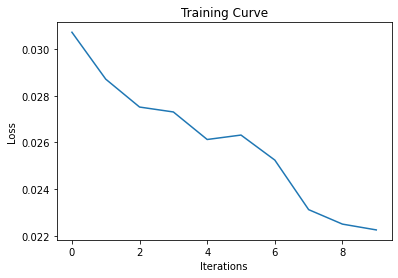

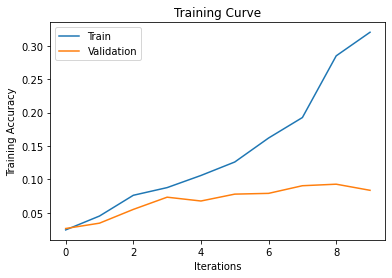

Final Training Accuracy: 0.320218
Final Validation Accuracy: 0.083524


In [ ]:
# Normal Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train(model, train_ds, val_ds, batch_size=128, num_epochs=10, learning_rate=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.023810, Validation Accuracy: 0.021739, Time: 1.19 minutes
Epoch: 2, Train Accuracy: 0.075464, Validation Accuracy: 0.051487, Time: 2.40 minutes
Epoch: 3, Train Accuracy: 0.150323, Validation Accuracy: 0.094966, Time: 3.61 minutes
Epoch: 4, Train Accuracy: 0.177563, Validation Accuracy: 0.086957, Time: 4.79 minutes
Epoch: 5, Train Accuracy: 0.224173, Validation Accuracy: 0.098398, Time: 6.00 minutes
Epoch: 6, Train Accuracy: 0.377119, Validation Accuracy: 0.114416, Time: 7.17 minutes
Epoch: 7, Train Accuracy: 0.492736, Validation Accuracy: 0.106407, Time: 8.34 minutes
Epoch: 8, Train Accuracy: 0.678975, Validation Accuracy: 0.110984, Time: 9.53 minutes
Epoch: 9, Train Accuracy: 0.867433, Validation Accuracy: 0.104119, Time: 10.76 minutes
Epoch: 10, Train Accuracy: 0.897094, Validation Accuracy: 0.074371, Time: 11.94 minutes
Finished Training
Total time elapsed: 12.09 minutes


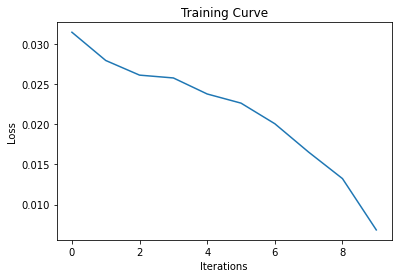

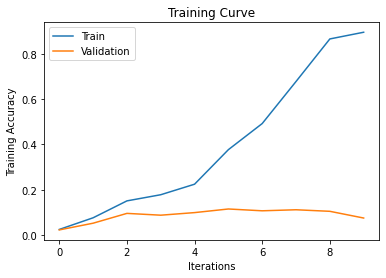

Final Training Accuracy: 0.897094
Final Validation Accuracy: 0.074371


In [ ]:
# Weight Decay Train + CNN Batch Norm
model = CNN_3_BN()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=10, learning_rate=0.001, weight_decay=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.024011, Validation Accuracy: 0.014874, Time: 1.21 minutes
Epoch: 2, Train Accuracy: 0.047417, Validation Accuracy: 0.052632, Time: 2.40 minutes
Epoch: 3, Train Accuracy: 0.087369, Validation Accuracy: 0.062929, Time: 3.63 minutes
Epoch: 4, Train Accuracy: 0.117635, Validation Accuracy: 0.096110, Time: 4.81 minutes
Epoch: 5, Train Accuracy: 0.144270, Validation Accuracy: 0.098398, Time: 6.02 minutes
Epoch: 6, Train Accuracy: 0.166868, Validation Accuracy: 0.092677, Time: 7.21 minutes
Epoch: 7, Train Accuracy: 0.221146, Validation Accuracy: 0.078947, Time: 8.40 minutes
Epoch: 8, Train Accuracy: 0.240315, Validation Accuracy: 0.081236, Time: 9.60 minutes
Epoch: 9, Train Accuracy: 0.283293, Validation Accuracy: 0.088101, Time: 10.81 minutes
Epoch: 10, Train Accuracy: 0.380952, Validation Accuracy: 0.097254, Time: 12.02 minutes
Finished Training
Total time elapsed: 12.17 minutes


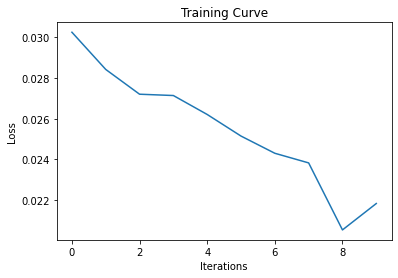

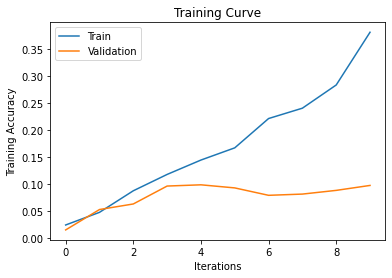

Final Training Accuracy: 0.380952
Final Validation Accuracy: 0.097254


In [ ]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=10, learning_rate=0.001, weight_decay=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.029257, Validation Accuracy: 0.021739, Time: 16.70 minutes
Epoch: 2, Train Accuracy: 0.076473, Validation Accuracy: 0.052632, Time: 17.96 minutes
Epoch: 3, Train Accuracy: 0.115214, Validation Accuracy: 0.075515, Time: 19.17 minutes
Epoch: 4, Train Accuracy: 0.166263, Validation Accuracy: 0.088101, Time: 20.37 minutes
Epoch: 5, Train Accuracy: 0.187853, Validation Accuracy: 0.076659, Time: 21.58 minutes
Epoch: 6, Train Accuracy: 0.249596, Validation Accuracy: 0.098398, Time: 22.81 minutes
Epoch: 7, Train Accuracy: 0.338378, Validation Accuracy: 0.096110, Time: 24.04 minutes
Epoch: 8, Train Accuracy: 0.383979, Validation Accuracy: 0.084668, Time: 25.25 minutes
Epoch: 9, Train Accuracy: 0.528249, Validation Accuracy: 0.075515, Time: 26.51 minutes
Epoch: 10, Train Accuracy: 0.603309, Validation Accuracy: 0.077803, Time: 27.73 minutes
Finished Training
Total time elapsed: 27.88 minutes


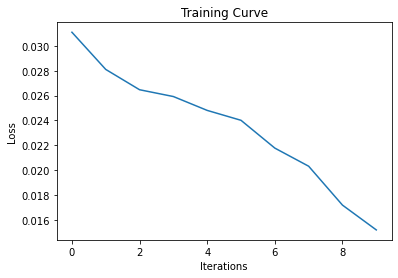

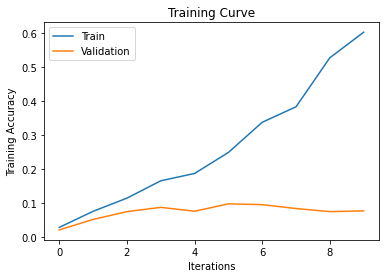

Final Training Accuracy: 0.603309
Final Validation Accuracy: 0.077803


In [ ]:
# Weight Decay Train + Drop Out 20%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=10, learning_rate=0.001, weight_decay=0.001)

### Test Out Different Combinations

In [ ]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=30, learning_rate=0.01, weight_decay=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.047619, Validation Accuracy: 0.022883, Time: 12.02 minutes
Epoch: 2, Train Accuracy: 0.090395, Validation Accuracy: 0.042334, Time: 13.25 minutes
Epoch: 3, Train Accuracy: 0.161622, Validation Accuracy: 0.058352, Time: 14.48 minutes
Epoch: 4, Train Accuracy: 0.225787, Validation Accuracy: 0.061785, Time: 15.72 minutes
Epoch: 5, Train Accuracy: 0.300444, Validation Accuracy: 0.059497, Time: 16.95 minutes
Epoch: 6, Train Accuracy: 0.432607, Validation Accuracy: 0.067506, Time: 18.16 minutes
Epoch: 7, Train Accuracy: 0.495964, Validation Accuracy: 0.060641, Time: 19.38 minutes
Epoch: 8, Train Accuracy: 0.640839, Validation Accuracy: 0.054920, Time: 20.63 minutes
Epoch: 9, Train Accuracy: 0.713680, Validation Accuracy: 0.061785, Time: 21.87 minutes
Epoch: 10, Train Accuracy: 0.779257, Validation Accuracy: 0.052632, Time: 23.08 minutes
Epoch: 11, Train Accuracy: 0.822639, Validation Accuracy: 0.045767, Time:

KeyboardInterrupt: ignored

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.030266, Validation Accuracy: 0.027460, Time: 14.59 minutes
Epoch: 2, Train Accuracy: 0.054479, Validation Accuracy: 0.054920, Time: 15.79 minutes
Epoch: 3, Train Accuracy: 0.111985, Validation Accuracy: 0.080092, Time: 17.00 minutes
Epoch: 4, Train Accuracy: 0.170904, Validation Accuracy: 0.089245, Time: 18.18 minutes
Epoch: 5, Train Accuracy: 0.234867, Validation Accuracy: 0.096110, Time: 19.38 minutes
Epoch: 6, Train Accuracy: 0.286118, Validation Accuracy: 0.099542, Time: 20.56 minutes
Epoch: 7, Train Accuracy: 0.359968, Validation Accuracy: 0.086957, Time: 21.80 minutes
Epoch: 8, Train Accuracy: 0.504237, Validation Accuracy: 0.077803, Time: 23.00 minutes
Epoch: 9, Train Accuracy: 0.677764, Validation Accuracy: 0.083524, Time: 24.22 minutes
Epoch: 10, Train Accuracy: 0.792776, Validation Accuracy: 0.096110, Time: 25.46 minutes
Epoch: 11, Train Accuracy: 0.852098, Validation Accuracy: 0.083524, Time:

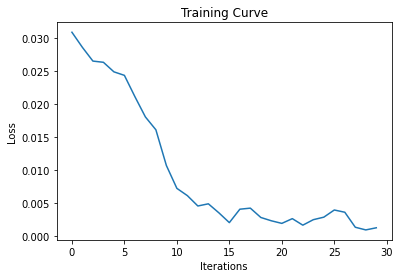

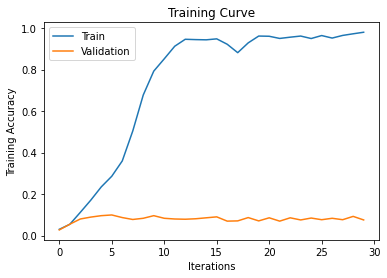

Final Training Accuracy: 0.980226
Final Validation Accuracy: 0.075515


In [ ]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=30, learning_rate=0.001, weight_decay=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.109362, Validation Accuracy: 0.051487, Time: 36.92 minutes
Epoch: 2, Train Accuracy: 0.216303, Validation Accuracy: 0.081236, Time: 38.10 minutes
Epoch: 3, Train Accuracy: 0.385997, Validation Accuracy: 0.099542, Time: 39.31 minutes
Epoch: 4, Train Accuracy: 0.523608, Validation Accuracy: 0.098398, Time: 40.47 minutes
Epoch: 5, Train Accuracy: 0.672720, Validation Accuracy: 0.090389, Time: 41.63 minutes
Epoch: 6, Train Accuracy: 0.818200, Validation Accuracy: 0.106407, Time: 42.82 minutes
Epoch: 7, Train Accuracy: 0.930993, Validation Accuracy: 0.088101, Time: 43.96 minutes
Epoch: 8, Train Accuracy: 0.969935, Validation Accuracy: 0.097254, Time: 45.13 minutes
Epoch: 9, Train Accuracy: 0.993947, Validation Accuracy: 0.091533, Time: 46.33 minutes
Epoch: 10, Train Accuracy: 0.997579, Validation Accuracy: 0.083524, Time: 47.49 minutes
Epoch: 11, Train Accuracy: 0.998588, Validation Accuracy: 0.094966, Time:

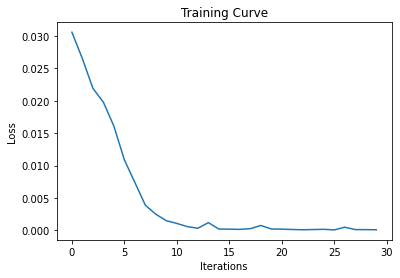

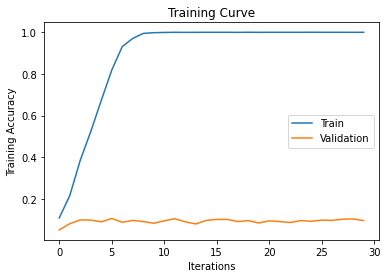

Final Training Accuracy: 0.999395
Final Validation Accuracy: 0.096110


In [ ]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=30, learning_rate=0.0001, weight_decay=0.001)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.115012, Validation Accuracy: 0.054920, Time: 28.66 minutes
Epoch: 2, Train Accuracy: 0.225585, Validation Accuracy: 0.104119, Time: 29.93 minutes
Epoch: 3, Train Accuracy: 0.373083, Validation Accuracy: 0.084668, Time: 31.16 minutes
Epoch: 4, Train Accuracy: 0.476190, Validation Accuracy: 0.107551, Time: 32.39 minutes
Epoch: 5, Train Accuracy: 0.609362, Validation Accuracy: 0.085812, Time: 33.65 minutes
Epoch: 6, Train Accuracy: 0.773608, Validation Accuracy: 0.104119, Time: 34.88 minutes
Epoch: 7, Train Accuracy: 0.874294, Validation Accuracy: 0.083524, Time: 36.11 minutes
Epoch: 8, Train Accuracy: 0.942897, Validation Accuracy: 0.092677, Time: 37.34 minutes
Epoch: 9, Train Accuracy: 0.980831, Validation Accuracy: 0.106407, Time: 38.58 minutes
Epoch: 10, Train Accuracy: 0.991324, Validation Accuracy: 0.089245, Time: 39.84 minutes
Epoch: 11, Train Accuracy: 0.994956, Validation Accuracy: 0.094966, Time:

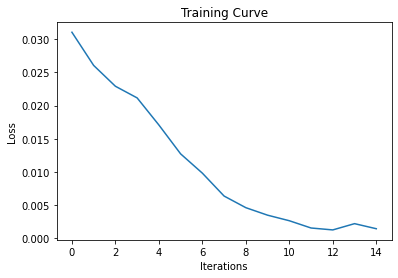

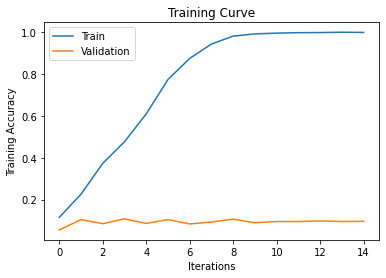

Final Training Accuracy: 0.998386
Final Validation Accuracy: 0.096110


In [20]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=15, learning_rate=0.0001, weight_decay=0.01)

CUDA is available!  Training on GPU ...
Starts Training
Epoch: 1, Train Accuracy: 0.124899, Validation Accuracy: 0.092677, Time: 1.23 minutes
Epoch: 2, Train Accuracy: 0.217312, Validation Accuracy: 0.093822, Time: 2.47 minutes
Epoch: 3, Train Accuracy: 0.341808, Validation Accuracy: 0.100686, Time: 3.70 minutes
Epoch: 4, Train Accuracy: 0.471146, Validation Accuracy: 0.123570, Time: 4.95 minutes
Epoch: 5, Train Accuracy: 0.613801, Validation Accuracy: 0.098398, Time: 6.19 minutes
Epoch: 6, Train Accuracy: 0.787127, Validation Accuracy: 0.109840, Time: 7.40 minutes
Epoch: 7, Train Accuracy: 0.909605, Validation Accuracy: 0.125858, Time: 8.66 minutes
Epoch: 8, Train Accuracy: 0.962873, Validation Accuracy: 0.110984, Time: 9.88 minutes
Epoch: 9, Train Accuracy: 0.993947, Validation Accuracy: 0.099542, Time: 11.11 minutes
Epoch: 10, Train Accuracy: 0.998789, Validation Accuracy: 0.097254, Time: 12.36 minutes
Epoch: 11, Train Accuracy: 0.997982, Validation Accuracy: 0.117849, Time: 13.59 m

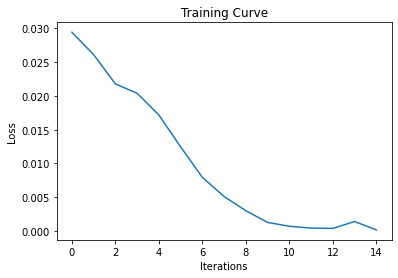

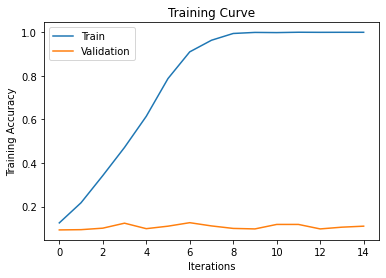

Final Training Accuracy: 0.999395
Final Validation Accuracy: 0.109840


In [21]:
# Weight Decay Train + Drop Out 10%
model = CNN_3_BN_DO()

use_cuda = True
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')

train_WD(model, train_ds, val_ds, batch_size=128, num_epochs=15, learning_rate=0.0001, weight_decay=0.0001)